# Residual Learning From Scratch
### Why very deep networks fail to train — and how a single "+ x" fixes it

This notebook builds an intuition for the **residual** the way a research engineer
would: start from the plain word, watch a concrete problem break, and then *derive*
the residual idea as the natural fix.

We will:

1. Pin down what the word *residual* means (statistics → deep learning).
2. Build a synthetic regression problem we can fully see and reproduce.
3. Train plain deep networks and **watch them get worse as they get deeper** — the
   *degradation problem* reported in the ResNet paper.
4. Diagnose *why* this happens (vanishing gradients).
5. **Derive** residual learning: `output = F(x) + x`.
6. Re-run the experiment and watch residual networks stay trainable at any depth.

Seminal references (full list at the end):

- He, Zhang, Ren & Sun (2015), *Deep Residual Learning for Image Recognition*, arXiv:1512.03385.
- Srivastava, Greff & Schmidhuber (2015), *Highway Networks*, arXiv:1505.00387.
- He, Zhang, Ren & Sun (2016), *Identity Mappings in Deep Residual Networks*, arXiv:1603.05027.

Everything here runs on CPU in a few minutes. Variable names are deliberately long
and the Python is deliberately plain — this is a teaching notebook, not production code.

## Part 0 — What does *residual* even mean?

"Residual" just means **what is left over**. If you have something, and you subtract
the part you can already explain, the *residual* is the leftover part.

### 0.1 The statistical residual (the familiar one)

In ordinary regression you predict a target `y` with a model, and the **residual**
of each data point is:

$$\text{residual} = y_{\text{observed}} - y_{\text{predicted}}$$

It is the error left over after the model has done its best. A model fits well when
its residuals are small and patternless.

Let's compute a few residuals by hand so the word is concrete before we reuse it.

In [1]:
import numpy as np

# A tiny made-up dataset: hours studied -> exam score
hours_studied   = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
observed_scores = np.array([52.0, 60.0, 67.0, 77.0, 84.0])

# Fit the simplest possible model: a straight line  score = slope*hours + intercept
slope, intercept = np.polyfit(hours_studied, observed_scores, deg=1)
predicted_scores = slope * hours_studied + intercept

# The residual is literally observed minus predicted: the leftover the line missed.
residuals = observed_scores - predicted_scores

print(f"fitted line:  score = {slope:.2f} * hours + {intercept:.2f}")
print()
print(f"{'hours':>6} {'observed':>9} {'predicted':>10} {'residual (leftover)':>20}")
for h, o, p, r in zip(hours_studied, observed_scores, predicted_scores, residuals):
    print(f"{h:>6.1f} {o:>9.1f} {p:>10.2f} {r:>20.2f}")

fitted line:  score = 8.10 * hours + 43.70

 hours  observed  predicted  residual (leftover)
   1.0      52.0      51.80                 0.20
   2.0      60.0      59.90                 0.10
   3.0      67.0      68.00                -1.00
   4.0      77.0      76.10                 0.90
   5.0      84.0      84.20                -0.20


The residual column is the heart of the word: **it is the part the model could not
explain.** Notice that if we *add the residual back* to the prediction, we exactly
recover the observation:

$$y_{\text{observed}} = y_{\text{predicted}} + \text{residual}$$

Hold onto that rearrangement — `observed = predicted + residual`. The whole idea of
*residual learning* in deep networks is going to be exactly this equation, read in a
clever direction.

### 0.2 From statistical residual to *residual function*

In a deep network, suppose a block of layers is *supposed* to compute some target
function `H(x)`. Instead of asking the layers to produce `H(x)` directly, we will ask
them to produce only the **residual function**

$$F(x) = H(x) - x$$

i.e. *what H needs to add to its own input*. Then we reconstruct the target by adding
the input back:

$$H(x) = F(x) + x$$

Same shape as `observed = predicted + residual`. The block learns the *leftover*
`F(x)`, and the `+ x` (called a **skip** or **shortcut** connection) carries the input
straight through. The rest of this notebook shows why this tiny re-parameterization is
the difference between a network that trains and one that doesn't.

## Part 1 — A problem we can fully see

To watch networks succeed and fail we want a problem that is:

- **small** (trains on a CPU in seconds),
- **reproducible** (same numbers every run), and
- **visualizable** (we can literally plot the function being learned).

So we use 1-D regression: learn a wiggly curve `y = f(x)` from input `x`. A neural
network fitting a curve is the simplest setting where *depth* matters, with nothing
else (images, data loaders, augmentation) to distract us.

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility: fix every random seed we touch.
RANDOM_SEED = 0
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("torch version:", torch.__version__)
print("running on   :", "cuda" if torch.cuda.is_available() else "cpu")

torch version: 2.12.1+cu130
running on   : cpu


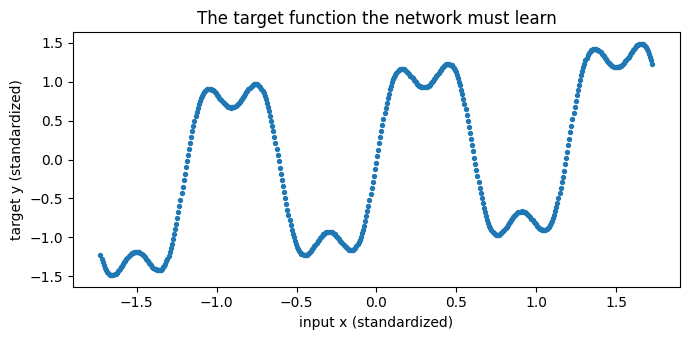

In [3]:
# ---- Build the synthetic dataset -------------------------------------------
number_of_points = 512

# Inputs: 512 evenly spaced points on [-3, 3], shaped as a column (N, 1).
inputs_x = torch.linspace(-3.0, 3.0, number_of_points).unsqueeze(1)

# The "true" function we want the network to discover: a couple of sine waves
# plus a gentle slope. Wiggly enough that a network actually has to work.
targets_y = torch.sin(3.0 * inputs_x) + 0.3 * torch.sin(9.0 * inputs_x) + 0.1 * inputs_x

# Standardize both to zero-mean / unit-variance. This is just good hygiene and it
# also makes the loss numbers easy to read: a model that gives up and predicts the
# average will sit at a mean-squared-error of ~1.0.
inputs_x  = (inputs_x  - inputs_x.mean())  / inputs_x.std()
targets_y = (targets_y - targets_y.mean()) / targets_y.std()

plt.figure(figsize=(7, 3.5))
plt.scatter(inputs_x.numpy(), targets_y.numpy(), s=8)
plt.title("The target function the network must learn")
plt.xlabel("input x (standardized)")
plt.ylabel("target y (standardized)")
plt.tight_layout()
plt.show()

## Part 2 — A plain deep network, and why we *expect* depth to help

A **plain** network just stacks layers: `Linear -> activation -> Linear -> activation -> ...`.
Each layer transforms the previous layer's output.

Here is the classic argument for why **deeper should never be worse**:

> Take any shallow network that works. Build a deeper network by appending extra layers.
> If those extra layers just learned the **identity** mapping (output = input), the
> deeper network would compute *exactly the same function* as the shallow one. So a
> deeper network can always *at least match* a shallower one — it has a strictly larger
> set of functions it could represent.

This is a statement about what the network *can represent*. As we'll see, it says
nothing about whether gradient descent can actually *find* that solution. That gap is
the whole story.

Let's define a plain network. The `depth` argument is how many hidden layers we stack.

In [4]:
class PlainNetwork(nn.Module):
    '''A plain feed-forward network: stack `depth` hidden layers, no shortcuts.'''

    def __init__(self, depth, width=64):
        super().__init__()

        list_of_layers = []

        # First layer maps the 1-D input up to `width` features.
        list_of_layers.append(nn.Linear(1, width))
        list_of_layers.append(nn.Tanh())

        # Then `depth` hidden layers, each width -> width followed by an activation.
        for hidden_layer_index in range(depth):
            list_of_layers.append(nn.Linear(width, width))
            list_of_layers.append(nn.Tanh())

        # Final layer maps the features back down to a single output number.
        list_of_layers.append(nn.Linear(width, 1))

        # nn.Sequential just calls each layer in order.
        self.stack_of_layers = nn.Sequential(*list_of_layers)

    def forward(self, x):
        return self.stack_of_layers(x)


# A small helper that trains any model on our dataset and returns the final
# TRAINING loss. We care about TRAINING loss specifically: if a deep network can't
# even fit the data it was trained on, that is NOT overfitting -- it is a failure
# to optimize.
def train_model_and_return_final_training_loss(model, number_of_epochs=1200, learning_rate=3e-3):
    optimizer    = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_function = nn.MSELoss()

    for epoch in range(number_of_epochs):
        optimizer.zero_grad()
        predictions = model(inputs_x)
        loss        = loss_function(predictions, targets_y)
        loss.backward()
        optimizer.step()

    return loss.item()

shallow plain network (depth=2) final training MSE: 0.0009


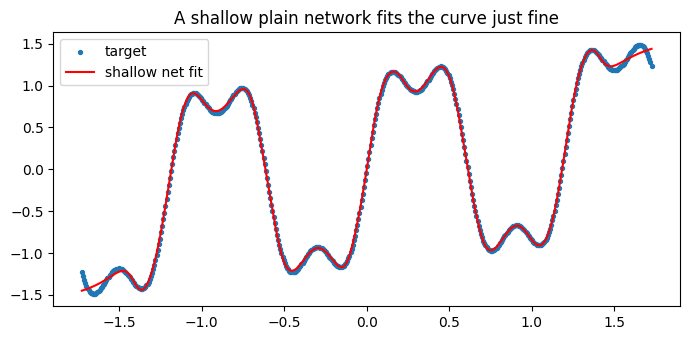

In [5]:
# Sanity check: a SHALLOW plain network should fit this curve easily.
torch.manual_seed(RANDOM_SEED)
shallow_plain_network = PlainNetwork(depth=2)
final_loss = train_model_and_return_final_training_loss(shallow_plain_network)
print(f"shallow plain network (depth=2) final training MSE: {final_loss:.4f}")

with torch.no_grad():
    shallow_predictions = shallow_plain_network(inputs_x)

plt.figure(figsize=(7, 3.5))
plt.scatter(inputs_x.numpy(), targets_y.numpy(), s=8, label="target")
plt.plot(inputs_x.numpy(), shallow_predictions.numpy(), color="red", label="shallow net fit")
plt.title("A shallow plain network fits the curve just fine")
plt.legend(); plt.tight_layout(); plt.show()

## Part 3 — The degradation problem (He et al., 2015)

Now the surprising part. The ResNet paper made a now-famous observation: when you keep
stacking plain layers, past some depth the network does not just stop improving — its
**training error gets worse**. Crucially this is *not* overfitting (that would raise
*test* error while training error keeps falling). The deeper plain network simply
becomes harder to optimize. The paper calls this the **degradation problem**.

Let's reproduce it. We train plain networks at increasing depths and record the final
**training** MSE for each. Remember the scale: an MSE near `1.0` means the network gave
up and is basically predicting the average.

In [6]:
depths_to_test = [2, 6, 12, 24, 40]

plain_network_training_losses = []
for depth in depths_to_test:
    torch.manual_seed(RANDOM_SEED)              # same init seed for a fair comparison
    network    = PlainNetwork(depth=depth)
    final_loss = train_model_and_return_final_training_loss(network)
    plain_network_training_losses.append(final_loss)
    print(f"plain network depth={depth:3d}  ->  final training MSE = {final_loss:.4f}")

plain network depth=  2  ->  final training MSE = 0.0009


plain network depth=  6  ->  final training MSE = 0.0085


plain network depth= 12  ->  final training MSE = 0.0042


plain network depth= 24  ->  final training MSE = 0.8818


plain network depth= 40  ->  final training MSE = 0.9218


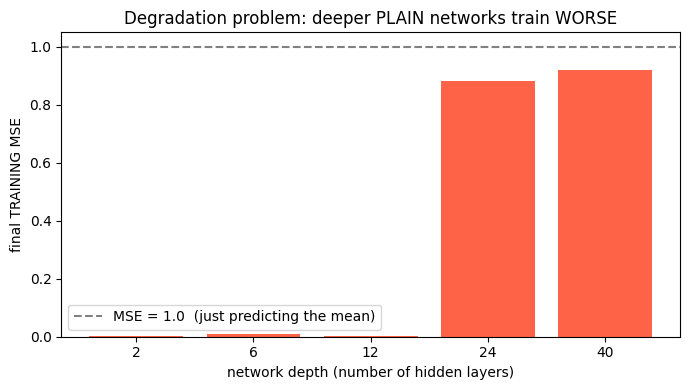

In [7]:
plt.figure(figsize=(7, 4))
plt.bar([str(d) for d in depths_to_test], plain_network_training_losses, color="tomato")
plt.axhline(1.0, linestyle="--", color="gray", label="MSE = 1.0  (just predicting the mean)")
plt.title("Degradation problem: deeper PLAIN networks train WORSE")
plt.xlabel("network depth (number of hidden layers)")
plt.ylabel("final TRAINING MSE")
plt.legend(); plt.tight_layout(); plt.show()

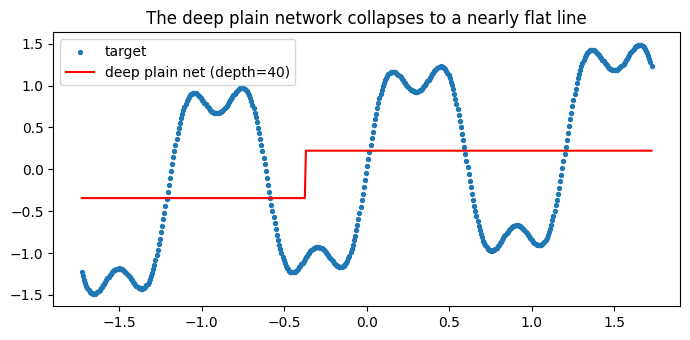

In [8]:
# What does a "degraded" deep plain network actually predict? Let's look.
torch.manual_seed(RANDOM_SEED)
deep_plain_network = PlainNetwork(depth=40)
train_model_and_return_final_training_loss(deep_plain_network)

with torch.no_grad():
    deep_plain_predictions = deep_plain_network(inputs_x)

plt.figure(figsize=(7, 3.5))
plt.scatter(inputs_x.numpy(), targets_y.numpy(), s=8, label="target")
plt.plot(inputs_x.numpy(), deep_plain_predictions.numpy(), color="red", label="deep plain net (depth=40)")
plt.title("The deep plain network collapses to a nearly flat line")
plt.legend(); plt.tight_layout(); plt.show()

The deep plain network barely bends — it has essentially collapsed to predicting the
mean. Yet by the identity argument in Part 2, this network *can represent* the good fit
the shallow network found. It just can't **reach** it with gradient descent. So the
problem is one of **optimization**, not capacity. Next we look at the mechanism.

## Part 4 — Why deep plain nets choke: vanishing gradients

When we backpropagate, the gradient at an early layer is a long product of the
Jacobians of all the later layers (chain rule). With saturating activations like
`tanh`, each factor in that product tends to be smaller than 1, so the product shrinks
**exponentially** as it travels backward through many layers. The early layers end up
receiving almost no gradient signal — so they barely learn. This is the classic
**vanishing-gradient** problem (Hochreiter 1991; Bengio, Simard & Frasconi 1994).

We can see it directly. Take a freshly initialized deep plain network, do a single
backward pass, and measure the gradient norm at each layer's weights.

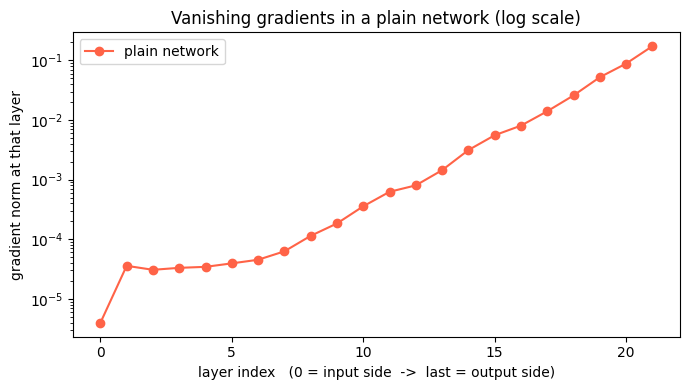

output-side gradient is ~43,725x larger than input-side gradient
=> the early layers receive almost no signal, so they barely learn.


In [9]:
def gradient_norm_at_each_layer(model):
    '''Run one forward+backward pass and return the gradient norm of each weight,
    ordered from the FIRST (input-side) layer to the LAST (output-side) layer.'''
    model.zero_grad()
    loss = nn.MSELoss()(model(inputs_x), targets_y)
    loss.backward()
    norms = [parameter.grad.norm().item()
             for name, parameter in model.named_parameters()
             if "weight" in name]
    return norms


torch.manual_seed(1)
plain_net_for_gradients = PlainNetwork(depth=20)
plain_gradient_norms = gradient_norm_at_each_layer(plain_net_for_gradients)

plt.figure(figsize=(7, 4))
plt.semilogy(range(len(plain_gradient_norms)), plain_gradient_norms,
             marker="o", color="tomato", label="plain network")
plt.title("Vanishing gradients in a plain network (log scale)")
plt.xlabel("layer index   (0 = input side  ->  last = output side)")
plt.ylabel("gradient norm at that layer")
plt.legend(); plt.tight_layout(); plt.show()

ratio = plain_gradient_norms[-1] / plain_gradient_norms[0]
print(f"output-side gradient is ~{ratio:,.0f}x larger than input-side gradient")
print("=> the early layers receive almost no signal, so they barely learn.")

## Part 5 — The residual idea (the derivation)

Here is the move. Recall from Part 0 the rearrangement `observed = predicted + residual`.

A block of layers is supposed to compute some target mapping `H(x)`. Two ways to ask
for it:

**Plain way.** Make the layers output `H(x)` directly.

**Residual way.** Make the layers output only the *residual* `F(x) = H(x) - x`, then add
the input back through a shortcut:

$$\text{block output} = F(x) + x$$

Algebraically these are identical (`F(x) + x = (H(x) - x) + x = H(x)`). But for the
*optimizer* they are very different:

1. **Identity becomes the easy default.** If the best thing a block can do is "leave the
   input alone" (the identity mapping), the plain block must laboriously learn the
   identity through nonlinear layers. The residual block only has to drive its weights
   toward **zero** so that `F(x) = 0` and the output is exactly `x`. Pushing weights to
   zero is the easiest thing gradient descent ever does.

2. **Gradients get a highway.** Differentiate the block output:

$$\frac{\partial (F(x) + x)}{\partial x} = \frac{\partial F(x)}{\partial x} + 1$$

   That **`+ 1`** means the gradient can always flow straight back through the shortcut,
   even when `∂F/∂x` is tiny. The exponential shrinking from Part 4 no longer cuts off
   the early layers.

This is exactly the construction in **He et al. (2015)**. The closely related
**Highway Networks** (Srivastava et al., 2015) introduced *learned gates* on the
shortcut; ResNet showed that a plain, ungated identity shortcut is enough — and a
follow-up, **He et al. (2016)**, showed that keeping the shortcut a *clean* identity
path makes very deep nets train best of all.

In [10]:
class ResidualBlock(nn.Module):
    '''One residual block: output = activation( x + F(x) ),
    where F is a tiny two-layer network. The 'x +' is the shortcut connection.'''

    def __init__(self, width=64):
        super().__init__()
        # F(x): the residual function the block actually learns.
        self.residual_function = nn.Sequential(
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, width),
        )
        self.activation_after_addition = nn.Tanh()

    def forward(self, x):
        leftover_F_of_x = self.residual_function(x)   # F(x)
        return self.activation_after_addition(x + leftover_F_of_x)   # x + F(x)


# Demonstration of point #1 above: if we ZERO the residual function's weights,
# the block computes the IDENTITY exactly. That is the "easy default" plain blocks lack.
demo_block = ResidualBlock()
for parameter in demo_block.residual_function.parameters():
    nn.init.zeros_(parameter)

some_input = torch.randn(4, 64)
with torch.no_grad():
    # With F = 0, output = activation(x + 0) = tanh(x). For small x, tanh(x) ~ x,
    # but the point is the shortcut hands the input straight through with no learning.
    output_with_zero_residual = demo_block(some_input)

print("residual function output when weights are zero (should be all zeros):")
print(demo_block.residual_function(some_input).abs().max().item(), "(max abs value)")
print("=> with F(x)=0 the block reduces to passing its input through the shortcut.")

residual function output when weights are zero (should be all zeros):
0.0 (max abs value)
=> with F(x)=0 the block reduces to passing its input through the shortcut.


In [11]:
class ResidualNetwork(nn.Module):
    '''Stack `number_of_blocks` residual blocks between an input and output layer.'''

    def __init__(self, number_of_blocks, width=64):
        super().__init__()
        self.input_layer  = nn.Sequential(nn.Linear(1, width), nn.Tanh())
        self.residual_blocks = nn.Sequential(
            *[ResidualBlock(width) for _ in range(number_of_blocks)]
        )
        self.output_layer = nn.Linear(width, 1)

    def forward(self, x):
        features = self.input_layer(x)
        features = self.residual_blocks(features)
        return self.output_layer(features)

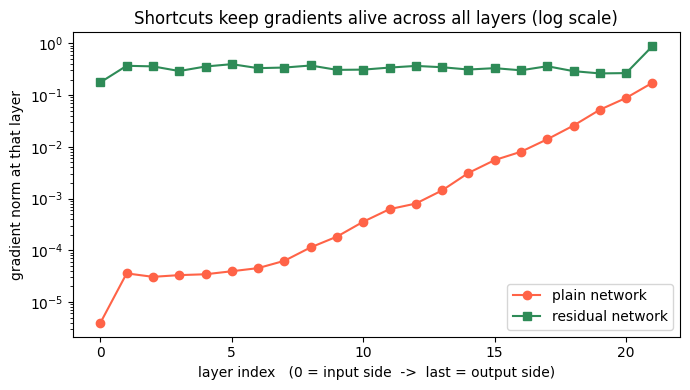

Plain  : gradient norms span many orders of magnitude (early layers starved).
Residual: gradient norms stay in a tight band -> every layer learns.


In [12]:
# Compare gradient flow: plain vs residual, both freshly initialized, both deep.
# Each residual block holds two linear layers, so we use half as many blocks to
# keep the total layer count comparable to the plain depth-20 network above.
torch.manual_seed(1)
residual_net_for_gradients = ResidualNetwork(number_of_blocks=10)
residual_gradient_norms = gradient_norm_at_each_layer(residual_net_for_gradients)

plt.figure(figsize=(7, 4))
plt.semilogy(range(len(plain_gradient_norms)), plain_gradient_norms,
             marker="o", color="tomato", label="plain network")
plt.semilogy(range(len(residual_gradient_norms)), residual_gradient_norms,
             marker="s", color="seagreen", label="residual network")
plt.title("Shortcuts keep gradients alive across all layers (log scale)")
plt.xlabel("layer index   (0 = input side  ->  last = output side)")
plt.ylabel("gradient norm at that layer")
plt.legend(); plt.tight_layout(); plt.show()

print("Plain  : gradient norms span many orders of magnitude (early layers starved).")
print("Residual: gradient norms stay in a tight band -> every layer learns.")

## Part 6 — The payoff

Now repeat the degradation experiment, but with residual networks, and put the two
side by side. This is the figure that made ResNet famous: residual networks keep
training well exactly where plain networks fall off a cliff.

In [13]:
residual_network_training_losses = []
for depth in depths_to_test:
    torch.manual_seed(RANDOM_SEED)
    # half as many blocks as `depth`, since each block contains two linear layers
    number_of_blocks = max(1, depth // 2)
    network    = ResidualNetwork(number_of_blocks=number_of_blocks)
    final_loss = train_model_and_return_final_training_loss(network)
    residual_network_training_losses.append(final_loss)
    print(f"residual network depth~{depth:3d}  ->  final training MSE = {final_loss:.4f}")

residual network depth~  2  ->  final training MSE = 0.0011


residual network depth~  6  ->  final training MSE = 0.0008


residual network depth~ 12  ->  final training MSE = 0.0006


residual network depth~ 24  ->  final training MSE = 0.0029


residual network depth~ 40  ->  final training MSE = 0.0028


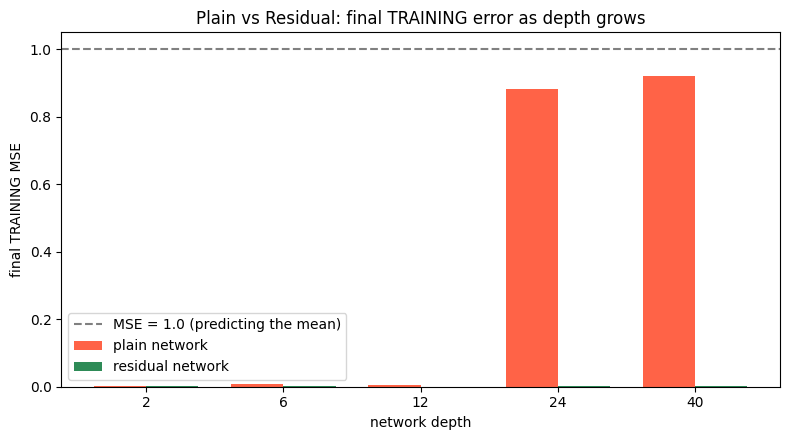

In [14]:
x_positions = np.arange(len(depths_to_test))
bar_width = 0.38

plt.figure(figsize=(8, 4.5))
plt.bar(x_positions - bar_width/2, plain_network_training_losses,
        width=bar_width, color="tomato",   label="plain network")
plt.bar(x_positions + bar_width/2, residual_network_training_losses,
        width=bar_width, color="seagreen", label="residual network")
plt.axhline(1.0, linestyle="--", color="gray", label="MSE = 1.0 (predicting the mean)")
plt.xticks(x_positions, [str(d) for d in depths_to_test])
plt.title("Plain vs Residual: final TRAINING error as depth grows")
plt.xlabel("network depth"); plt.ylabel("final TRAINING MSE")
plt.legend(); plt.tight_layout(); plt.show()

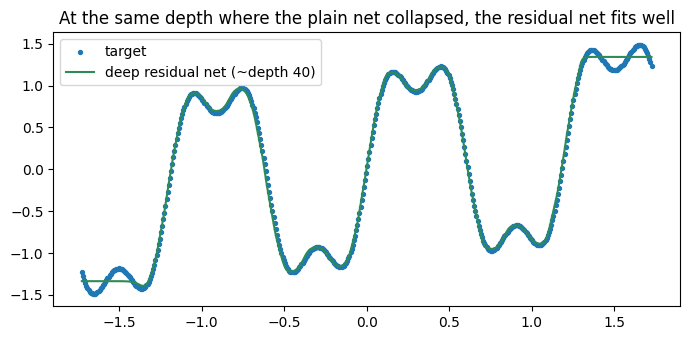

In [15]:
# And the fit of a DEEP residual network -- the depth that made the plain net collapse.
torch.manual_seed(RANDOM_SEED)
deep_residual_network = ResidualNetwork(number_of_blocks=20)   # ~depth 40
train_model_and_return_final_training_loss(deep_residual_network)

with torch.no_grad():
    deep_residual_predictions = deep_residual_network(inputs_x)

plt.figure(figsize=(7, 3.5))
plt.scatter(inputs_x.numpy(), targets_y.numpy(), s=8, label="target")
plt.plot(inputs_x.numpy(), deep_residual_predictions.numpy(),
         color="seagreen", label="deep residual net (~depth 40)")
plt.title("At the same depth where the plain net collapsed, the residual net fits well")
plt.legend(); plt.tight_layout(); plt.show()

## Part 7 — Recap and where residuals live today

**The one-line idea.** Instead of asking layers to learn a target mapping `H(x)`
outright, ask them to learn the *leftover* `F(x) = H(x) - x` and add the input back:
`H(x) = F(x) + x`. The added input is a **skip / shortcut connection**.

**Why it works.**

| Problem (plain deep net) | What the residual fixes |
|---|---|
| Identity is *hard* to learn through nonlinear layers | Identity is the *default*: drive `F(x) → 0` |
| Gradients vanish exponentially with depth | The shortcut adds a `+1` term, giving gradients a clean path back |
| Training error *grows* past some depth (degradation) | Training stays stable as depth grows |

**The big picture.** The identity argument in Part 2 was right that deeper networks can
*represent* more. The missing piece was *optimization* — and a single additive shortcut
is what makes those representable solutions actually *reachable* by gradient descent.

**Where you'll meet residuals now.** They are everywhere deep:
- **ResNets** for vision (the original use; a 152-layer ResNet won the ImageNet challenge in 2015).
- **Transformers** — every block wraps a residual connection around the attention sub-layer and around the feed-forward sub-layer (Vaswani et al., 2017). Without them, deep Transformers don't train.
- Diffusion U-Nets, deep RL networks, graph networks — the same `+ x` trick.

### Seminal references

- K. He, X. Zhang, S. Ren, J. Sun. **Deep Residual Learning for Image Recognition.** arXiv:1512.03385 (2015); CVPR 2016. *Introduces the degradation problem and the residual block.*
- R. K. Srivastava, K. Greff, J. Schmidhuber. **Highway Networks.** arXiv:1505.00387 (2015). *Learned gates on shortcut connections — a direct precursor.*
- K. He, X. Zhang, S. Ren, J. Sun. **Identity Mappings in Deep Residual Networks.** arXiv:1603.05027 (2016); ECCV 2016. *Shows a clean identity shortcut path trains the deepest nets best (pre-activation).*
- S. Hochreiter (1991) diploma thesis; Y. Bengio, P. Simard, P. Frasconi. **Learning long-term dependencies with gradient descent is difficult.** IEEE TNN (1994). *The vanishing-gradient problem residuals help with.*
- A. Vaswani et al. **Attention Is All You Need.** arXiv:1706.03762 (2017). *Residual connections inside every Transformer block.*

### Try it yourself (exercises)

1. Swap `nn.Tanh()` for `nn.ReLU()` everywhere. Does the plain net degrade at a different
   depth? Why might ReLU partly delay (but not cure) the problem?
2. Add `nn.BatchNorm1d(width)` inside the plain layers. How much does normalization help
   *on its own*, before any shortcut?
3. In `ResidualBlock.forward`, delete the `x +` and re-run Part 6. Watch the residual
   network turn back into a plain network and collapse — proof the shortcut is the
   active ingredient.
4. Make the shortcut a clean identity by moving the final activation *inside*
   `residual_function` (pre-activation style, He et al. 2016) and compare gradient flow.